# Regression & Classification with Apache Spark MLlib

**Dataset**: E-commerce event log with columns: `event_type`, `product_id`, `brand`, `price`, `user_id`, `user_session`, `product_name`, `category`, `hour`, `day`, `month`, `year`

## Tasks
| Task | Type | Target | Algorithm |
|------|------|--------|-----------|
| Predict product **price** | Regression | `price` (continuous) | Linear Regression |
| Predict **event type** (purchase vs cart) | Classification | `event_type` (binary) | Logistic Regression |

## Pipeline
1. Spark Session
2. Load & Explore
3. Feature Engineering
4. **Regression** — predict `price` (Linear Regression)
5. **Classification** — predict `event_type` (Logistic Regression)
6. Evaluation & Visualizations


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler,
    StandardScaler
)
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import (
    RegressionEvaluator, BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
spark = SparkSession.builder \
    .appName("Regression_Classification_Ecommerce") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")


In [5]:
DATA_PATH = "part-00000-592294fe-0de3-464a-b8ed-3c5026285aa9-c000.csv"

df = spark.read.csv(DATA_PATH, header=True, inferSchema=True)
print(f"Rows    : {df.count():,}")
print(f"Columns : {df.columns}")
df.printSchema()

Rows    : 134,995
Columns : ['event_type', 'product_id', 'brand', 'price', 'user_id', 'user_session', 'product_name', 'category', 'hour', 'day', 'month', 'year']
root
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- year: integer (nullable = true)



In [6]:
df.show(5)
df.select("price", "hour", "day", "month").describe().show()
print("\n=== event_type distribution ===")
df.groupBy("event_type").count().show()

print("\n=== Top categories ===")
df.groupBy("category").count().orderBy(F.desc("count")).show(10)

print("\n=== Top brands ===")
df.groupBy("brand").count().orderBy(F.desc("count")).show(10)

+----------+----------+-------+------+---------+--------------------+------------+-----------+----+---+-----+----+
|event_type|product_id|  brand| price|  user_id|        user_session|product_name|   category|hour|day|month|year|
+----------+----------+-------+------+---------+--------------------+------------+-----------+----+---+-----+----+
|  purchase|   1004856|samsung|130.76|543272936|8187d148-3c41-46d...|  smartphone|electronics|   0|  3|   10|2019|
|  purchase|   1002532|  apple|642.69|551377651|3c80f0d6-e9ec-418...|  smartphone|electronics|   0|  3|   10|2019|
|  purchase|  13800054|santeri| 54.42|555332717|1dea3ee2-2ded-42e...|    bathroom|  furniture|   0|  3|   10|2019|
|  purchase|   4804055|  apple|189.91|524601178|2af9b570-0942-4dc...|       audio|electronics|   0|  3|   10|2019|
|      cart|   1002524|  apple|515.67|524325294|0b74a829-f9d7-465...|  smartphone|electronics|   0|  3|   10|2019|
+----------+----------+-------+------+---------+--------------------+-----------

## 3. Feature Engineering (Shared)

Both models share the same feature set. We encode categorical columns (`brand`, `category`, `event_type`) using **StringIndexer → OneHotEncoder**, then assemble all features into a single vector.

In [7]:
data = df.select(
    "event_type", "price", "brand", "category", "hour", "day", "month"
).dropna()

print(f"Rows after dropping nulls: {data.count():,}")

Rows after dropping nulls: 134,995


In [8]:

# StringIndexer: converts string labels to numeric indices
brand_indexer    = StringIndexer(inputCol="brand",    outputCol="brand_idx",    handleInvalid="keep")
category_indexer = StringIndexer(inputCol="category", outputCol="category_idx", handleInvalid="keep")
event_indexer    = StringIndexer(inputCol="event_type",outputCol="label",        handleInvalid="keep")
# OneHotEncoder: converts indices to binary vectors
encoder = OneHotEncoder(
    inputCols=["brand_idx", "category_idx"],
    outputCols=["brand_vec", "category_vec"]
)

feature_cols = ["brand_vec", "category_vec", "hour", "day", "month"]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
)

preprocessing = Pipeline(stages=[
    brand_indexer,
    category_indexer,
    event_indexer,
    encoder,
    assembler,
    scaler
])

preprocessor = preprocessing.fit(data)
prepared     = preprocessor.transform(data)

print("Preprocessing done. Sample output:")
prepared.select("event_type", "label", "price", "features").show(5, truncate=True)

Preprocessing done. Sample output:
+----------+-----+------+--------------------+
|event_type|label| price|            features|
+----------+-----+------+--------------------+
|  purchase|  2.0|130.76|(1036,[0,1020,103...|
|  purchase|  2.0|642.69|(1036,[1,1020,103...|
|  purchase|  2.0| 54.42|(1036,[298,1026,1...|
|  purchase|  2.0|189.91|(1036,[1,1020,103...|
|      cart|  1.0|515.67|(1036,[1,1020,103...|
+----------+-----+------+--------------------+
only showing top 5 rows


---
## 4. REGRESSION — Predict `price`

**Target**: `price` (continuous)  
**Features**: brand, category, hour, day, month  
**Model**: Linear Regression  
**Metrics**: RMSE, MAE, R²


In [9]:
# Train / Test split
reg_data = prepared.select("features", "price").withColumnRenamed("price", "label")

reg_train, reg_test = reg_data.randomSplit([0.8, 0.2], seed=42)
print(f"Regression — Train: {reg_train.count():,}  |  Test: {reg_test.count():,}")

Regression — Train: 108,007  |  Test: 26,988


In [10]:
lr = LinearRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.1,
    elasticNetParam=0
)

lr_model = lr.fit(reg_train)

# Training summary
lr_summary = lr_model.summary
print(f"Linear Regression — Training RMSE : {lr_summary.rootMeanSquaredError:.4f}")
print(f"Linear Regression — Training R²   : {lr_summary.r2:.4f}")
print(f"Intercept : {lr_model.intercept:.4f}")

Linear Regression — Training RMSE : 284.4152
Linear Regression — Training R²   : 0.4882
Intercept : 359.5300


In [11]:
# Evaluate
lr_preds = lr_model.transform(reg_test)

reg_evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
reg_evaluator_mae  = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
reg_evaluator_r2   = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

lr_rmse = reg_evaluator_rmse.evaluate(lr_preds)
lr_mae  = reg_evaluator_mae.evaluate(lr_preds)
lr_r2   = reg_evaluator_r2.evaluate(lr_preds)

print("\n=== Linear Regression — Test Set Results ===")
print(f"  RMSE : {lr_rmse:.4f}")
print(f"  MAE  : {lr_mae:.4f}")
print(f"  R²   : {lr_r2:.4f}")

lr_preds.select("label", "prediction").show(10)


=== Linear Regression — Test Set Results ===
  RMSE : 284.6647
  MAE  : 177.0149
  R²   : 0.4796
+------+------------------+
| label|        prediction|
+------+------------------+
|286.86|320.31536012062264|
| 12.48| 320.9863725259254|
| 38.24| 320.9863725259254|
| 92.64| 320.9863725259254|
| 92.64| 320.9863725259254|
| 92.64| 320.9863725259254|
| 107.8| 320.9863725259254|
|130.73| 320.9863725259254|
|130.76| 320.9863725259254|
|130.76| 320.9863725259254|
+------+------------------+
only showing top 10 rows


---
## 5. CLASSIFICATION — Predict `event_type` (purchase vs cart)

**Target**: `event_type` → binary label (0 = cart, 1 = purchase)  
**Features**: brand, category, price, hour, day, month  
**Model**: Logistic Regression  
**Metrics**: Accuracy, Precision, Recall, F1, AUC-ROC


In [12]:
assembler_clf = VectorAssembler(
    inputCols=["brand_vec", "category_vec", "price", "hour", "day", "month"],
    outputCol="features_raw_clf"
)
scaler_clf = StandardScaler(
    inputCol="features_raw_clf",
    outputCol="features_clf",
    withStd=True,
    withMean=False
)

# Filter  binary classification (
binary_clf_data = prepared.filter(F.col("event_type").isin("purchase", "cart"))

binary_label_indexer = StringIndexer(inputCol="event_type", outputCol="binary_label", handleInvalid="error")
binary_clf_data = binary_label_indexer.fit(binary_clf_data).transform(binary_clf_data)
clf_prep = Pipeline(stages=[assembler_clf, scaler_clf]).fit(binary_clf_data)
clf_data = clf_prep.transform(binary_clf_data).select("features_clf", "binary_label")
clf_data = clf_data.withColumnRenamed("features_clf", "features").withColumnRenamed("binary_label", "label")

clf_train, clf_test = clf_data.randomSplit([0.8, 0.2], seed=42)
print(f"Classification — Train: {clf_train.count():,}  |  Test: {clf_test.count():,}")

print("\nClass distribution in training set:")
clf_train.groupBy("label").count().show()

Classification — Train: 19,786  |  Test: 4,911

Class distribution in training set:
+-----+-----+
|label|count|
+-----+-----+
|  1.0| 9720|
|  0.0|10066|
+-----+-----+



###Logistic Regression


In [13]:
log_reg = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.1,
    elasticNetParam=0,

)

log_reg_model = log_reg.fit(clf_train)

# Training summary
lr_clf_summary = log_reg_model.summary
print(f"Logistic Regression — Training Accuracy : {lr_clf_summary.accuracy:.4f}")
print(f"Logistic Regression — Training AUC-ROC  : {lr_clf_summary.areaUnderROC:.4f}")

Logistic Regression — Training Accuracy : 0.6174
Logistic Regression — Training AUC-ROC  : 0.6414


In [14]:
# Evaluate on test set
log_reg_preds = log_reg_model.transform(clf_test)

bin_evaluator   = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
mc_evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
mc_evaluator_f1  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
mc_evaluator_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
mc_evaluator_rec  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

def evaluate_classifier(preds, name):
    auc  = bin_evaluator.evaluate(preds)
    acc  = mc_evaluator_acc.evaluate(preds)
    f1   = mc_evaluator_f1.evaluate(preds)
    prec = mc_evaluator_prec.evaluate(preds)
    rec  = mc_evaluator_rec.evaluate(preds)
    print(f"\n=== {name} — Test Set Results ===")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC-ROC": auc}

lr_clf_metrics = evaluate_classifier(log_reg_preds, "Logistic Regression")

print("\nSample Predictions:")
log_reg_preds.select("label", "prediction", "probability").show(10)


=== Logistic Regression — Test Set Results ===
  Accuracy  : 0.6031
  Precision : 0.6753
  Recall    : 0.6031
  F1 Score  : 0.5573
  AUC-ROC   : 0.6285

Sample Predictions:
+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  1.0|       0.0|[0.57373343059943...|
|  1.0|       0.0|[0.58737281869691...|
|  0.0|       0.0|[0.59224456362270...|
|  0.0|       0.0|[0.59207595844826...|
|  1.0|       0.0|[0.56448645142382...|
|  1.0|       0.0|[0.58933220953131...|
|  1.0|       0.0|[0.55507650428628...|
|  1.0|       0.0|[0.56622508207119...|
|  0.0|       0.0|[0.58006585951718...|
|  0.0|       0.0|[0.58006585951718...|
+-----+----------+--------------------+
only showing top 10 rows


###  Confusion Matrix


In [15]:
def confusion_matrix_spark(preds, model_name):
    """Compute and display confusion matrix from Spark predictions."""
    cm = preds.groupBy("label", "prediction").count().orderBy("label", "prediction").toPandas()
    print(f"\n=== Confusion Matrix — {model_name} ===")
    print(cm.to_string(index=False))
    return cm

lr_cm = confusion_matrix_spark(log_reg_preds, "Logistic Regression")



=== Confusion Matrix — Logistic Regression ===
 label  prediction  count
   0.0         0.0   2272
   0.0         1.0    186
   1.0         0.0   1763
   1.0         1.0    690


---
## 6. Visualizations


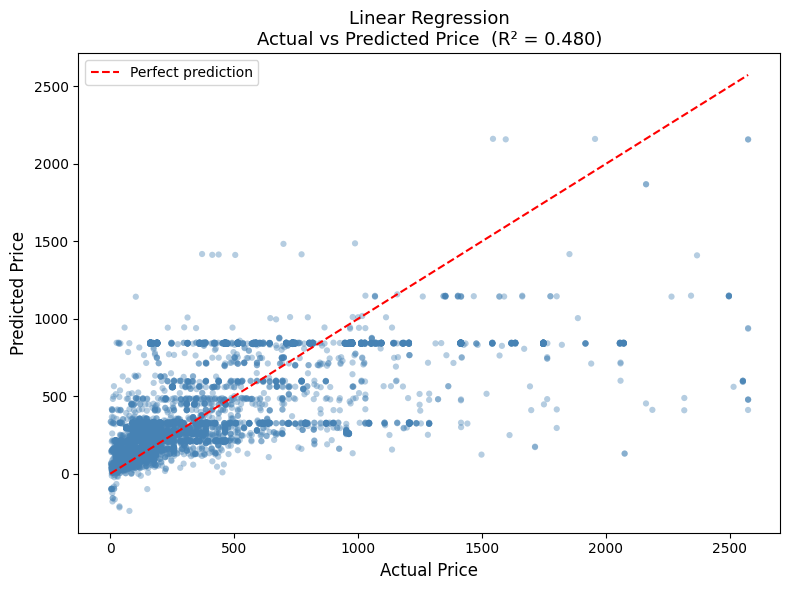

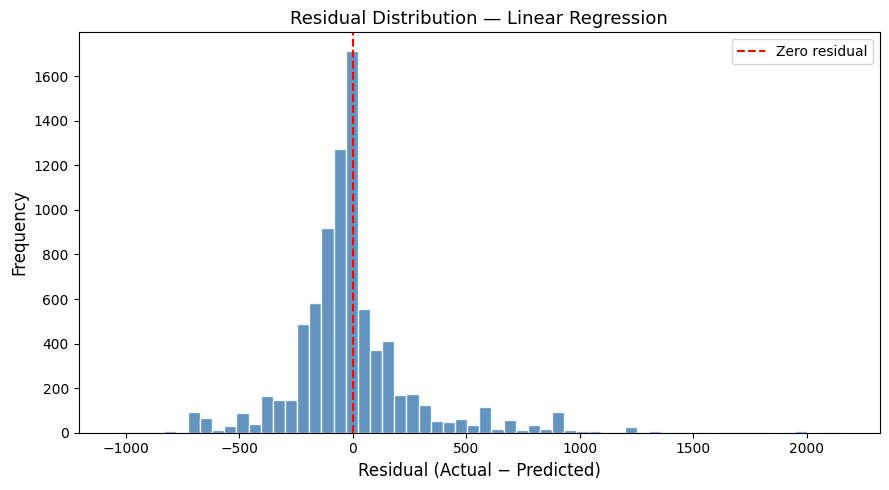

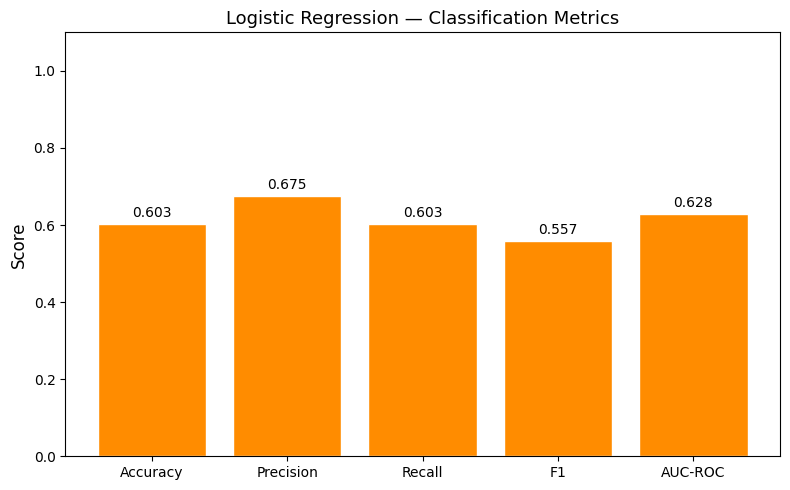

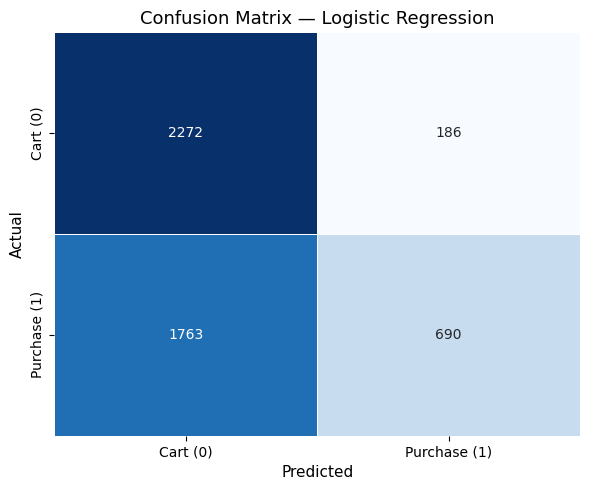

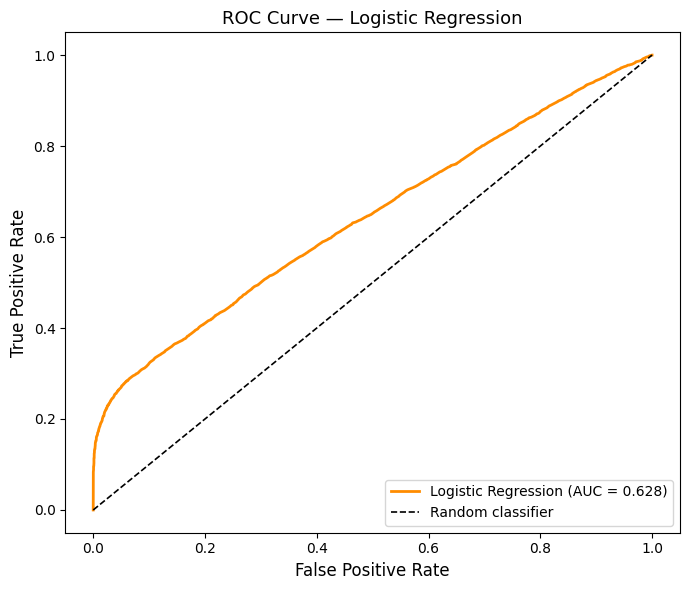

In [16]:
# ── Plot 1: Actual vs Predicted Price (Linear Regression) ────────────────────
preds_pd = lr_preds.select("label", "prediction").sample(fraction=0.3, seed=42).toPandas()

plt.figure(figsize=(8, 6))
plt.scatter(preds_pd["label"], preds_pd["prediction"], alpha=0.4, edgecolors='none', color='steelblue', s=20)
max_val = max(preds_pd["label"].max(), preds_pd["prediction"].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual Price", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)
plt.title(f"Linear Regression\nActual vs Predicted Price  (R² = {lr_r2:.3f})", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig("reg_actual_vs_predicted.png", dpi=150)
plt.show()

# ── Plot 2: Residuals Distribution ───────────────────────────────────────────
preds_pd["residual"] = preds_pd["label"] - preds_pd["prediction"]

plt.figure(figsize=(9, 5))
plt.hist(preds_pd["residual"], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
plt.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero residual")
plt.xlabel("Residual (Actual − Predicted)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Residual Distribution — Linear Regression", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig("reg_residuals.png", dpi=150)
plt.show()

# ── Plot 3: Classification Metrics Bar Chart ──────────────────────────────────
metrics = {"Accuracy": lr_clf_metrics["Accuracy"], "Precision": lr_clf_metrics["Precision"],
           "Recall": lr_clf_metrics["Recall"], "F1": lr_clf_metrics["F1"], "AUC-ROC": lr_clf_metrics["AUC-ROC"]}

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics.keys(), metrics.values(), color="darkorange", edgecolor="white")
plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
plt.ylim(0, 1.1)
plt.ylabel("Score", fontsize=12)
plt.title("Logistic Regression — Classification Metrics", fontsize=13)
plt.tight_layout()
plt.savefig("clf_metrics.png", dpi=150)
plt.show()

# ── Plot 4: Confusion Matrix Heatmap ─────────────────────────────────────────
import numpy as np

def cm_to_matrix(cm_pd):
    mat = np.zeros((2, 2), dtype=int)
    for _, row in cm_pd.iterrows():
        mat[int(row['label'])][int(row['prediction'])] += int(row['count'])
    return mat

mat = cm_to_matrix(lr_cm)
labels = ["Cart (0)", "Purchase (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, linewidths=0.5, cbar=False)
plt.title("Confusion Matrix — Logistic Regression", fontsize=13)
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("Actual", fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ── Plot 5: ROC Curve ─────────────────────────────────────────────────────────
roc_pd = lr_clf_summary.roc.toPandas()

plt.figure(figsize=(7, 6))
plt.plot(roc_pd["FPR"], roc_pd["TPR"], color='darkorange', lw=2,
         label=f"Logistic Regression (AUC = {lr_clf_metrics['AUC-ROC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1.2, label="Random classifier")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — Logistic Regression", fontsize=13)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()


In [17]:
reg_results_df = pd.DataFrame([{
    "Model": "Linear Regression", "RMSE": lr_rmse, "MAE": lr_mae, "R2": lr_r2
}])
clf_results_df = pd.DataFrame([lr_clf_metrics])

reg_results_df.to_csv("regression_results.csv", index=False)
clf_results_df.to_csv("classification_results.csv", index=False)
spark.stop()

Saved: regression_results.csv
Saved: classification_results.csv
Spark session stopped.
